In [1]:
from keras.layers import Input, Lambda, Dense, Flatten , GlobalAveragePooling2D
from keras.models import Model
from keras.applications.vgg19 import VGG19
from keras.applications.vgg19 import preprocess_input
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import tensorflow as tf

# Configure GPU memory growth to prevent OOM errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"[OK] GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)


[OK] GPU memory growth enabled for 1 GPU(s)


In [2]:
# data loading by using keras with automatic train/validation split
# Reduced batch_size to 16 to prevent GPU memory issues
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

training_set = train_datagen.flow_from_directory(
    'removed background',
    target_size=(224, 224),
    batch_size=16,  # Reduced from 32 to prevent OOM
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)


Found 4215 images belonging to 20 classes.


In [3]:
validation_set = train_datagen.flow_from_directory(
    'removed background',
    target_size=(224, 224),
    batch_size=16,  # Reduced from 32 to prevent OOM
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)


Found 1046 images belonging to 20 classes.


In [4]:
# Load the base model
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


In [5]:
# Freeze all the dense layers
for layer in base_model.layers:
    layer.trainable = False


In [6]:
# Define the model
from tensorflow.keras.layers import Dropout , GlobalAveragePooling2D
model = Sequential([
    base_model,
    GlobalAveragePooling2D(), # flatten()
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(20, activation='softmax')
])


In [7]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 7, 7, 512)         20024384  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1024)              525312    
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 20)                20500     
                                                                 
Total params: 20,570,196
Trainable params: 545,812
Non-trainable params: 20,024,384
______________________________________

In [8]:
# Compile the model
from tensorflow.keras.optimizers import Adam
# Increased learning rate slightly for VGG19 to help with underfitting
model.compile(optimizer=Adam(learning_rate=2e-5), loss='categorical_crossentropy', metrics=['accuracy'])


In [9]:
from keras.callbacks import EarlyStopping, ModelCheckpoint
from pathlib import Path

# Create callbacks list
callback = [
    EarlyStopping(
        monitor="val_accuracy",
        min_delta=0.00001,
        patience=45,
        verbose=1,
        mode="auto",
        baseline=None,
        restore_best_weights=True # false
    ),
    ModelCheckpoint(
        filepath="VGG19_best_model.keras",
        monitor="val_accuracy",
        verbose=1,
        save_best_only=True,
        mode="max",  # Changed to "max" because higher accuracy is better
        save_weights_only=False
    )
]


In [10]:
# Fit the model
training_model=model.fit(training_set, epochs=150, validation_data=validation_set , callbacks=callback)


Epoch 1/150
264/264 [==============================] - ETA: 0s - loss: 3.0606 - accuracy: 0.0558
Epoch 1: val_accuracy improved from -inf to 0.16157, saving model to VGG19_best_model.keras
264/264 [==============================] - 184s 679ms/step - loss: 3.0606 - accuracy: 0.0558 - val_loss: 2.9308 - val_accuracy: 0.1616
Epoch 2/150
264/264 [==============================] - ETA: 0s - loss: 2.9595 - accuracy: 0.0880
Epoch 2: val_accuracy improved from 0.16157 to 0.22849, saving model to VGG19_best_model.keras
264/264 [==============================] - 139s 525ms/step - loss: 2.9595 - accuracy: 0.0880 - val_loss: 2.8728 - val_accuracy: 0.2285
Epoch 3/150
264/264 [==============================] - ETA: 0s - loss: 2.8936 - accuracy: 0.1170
Epoch 3: val_accuracy improved from 0.22849 to 0.25048, saving model to VGG19_best_model.keras
264/264 [==============================] - 134s 508ms/step - loss: 2.8936 - accuracy: 0.1170 - val_loss: 2.8156 - val_accuracy: 0.2505
Epoch 4/150
264/264 [=

In [11]:
# model evaluation on training set
training_set.reset()
training_loss , train_accuracy = model.evaluate(training_set)


264/264 [==============================] - 104s 392ms/step - loss: 0.6750 - accuracy: 0.8119


In [12]:
# model evaluation on validation set
validation_set.reset()
validation_loss , validation_accuracy = model.evaluate(validation_set)


66/66 [==============================] - 28s 414ms/step - loss: 1.0794 - accuracy: 0.6979


In [13]:
tf.keras.callbacks.History()


In [14]:
training_model.history


{'loss': [3.060579299926758,
  2.95951247215271,
  2.893594264984131,
  2.830160140991211,
  2.760448455810547,
  2.6848185062408447,
  2.6442930698394775,
  2.5801455974578857,
  2.506227731704712,
  2.4531517028808594,
  2.3990604877471924,
  2.3357315063476562,
  2.284139633178711,
  2.2306618690490723,
  2.177159547805786,
  2.12213397026062,
  2.086069107055664,
  2.0392141342163086,
  1.9931049346923828,
  1.9584475755691528,
  1.9160361289978027,
  1.8783135414123535,
  1.8431910276412964,
  1.8112536668777466,
  1.7755731344223022,
  1.7380261421203613,
  1.7141411304473877,
  1.6882086992263794,
  1.6652973890304565,
  1.6323145627975464,
  1.6060823202133179,
  1.5898568630218506,
  1.5643267631530762,
  1.5377370119094849,
  1.5241013765335083,
  1.5104268789291382,
  1.4884542226791382,
  1.4590203762054443,
  1.4499861001968384,
  1.424308180809021,
  1.4093191623687744,
  1.3898242712020874,
  1.3746503591537476,
  1.3713440895080566,
  1.3412420749664307,
  1.34455180168

In [15]:
# record the history in json format

import json
with open("training_hist_VGG19_version_2.json" , "w") as f:
    json.dump(training_model.history , f)


In [16]:
# viz
# Create epochs list based on actual number of epochs trained (not fixed 150)
epochs = list(range(1, len(training_model.history['accuracy']) + 1))
epochs


[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150]

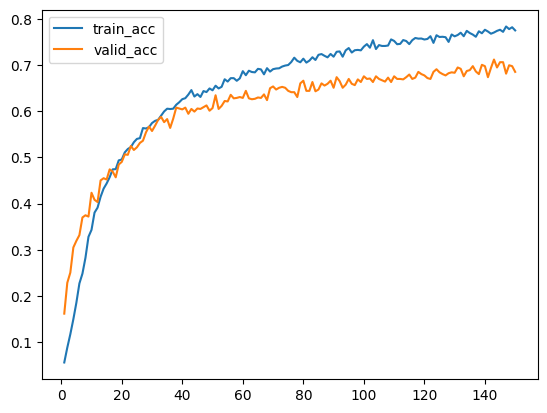

In [17]:
plt.plot(epochs,training_model.history['accuracy'] , label = 'train_acc')
plt.plot(epochs,training_model.history['val_accuracy'] , label='valid_acc')
plt.legend()
plt.show()


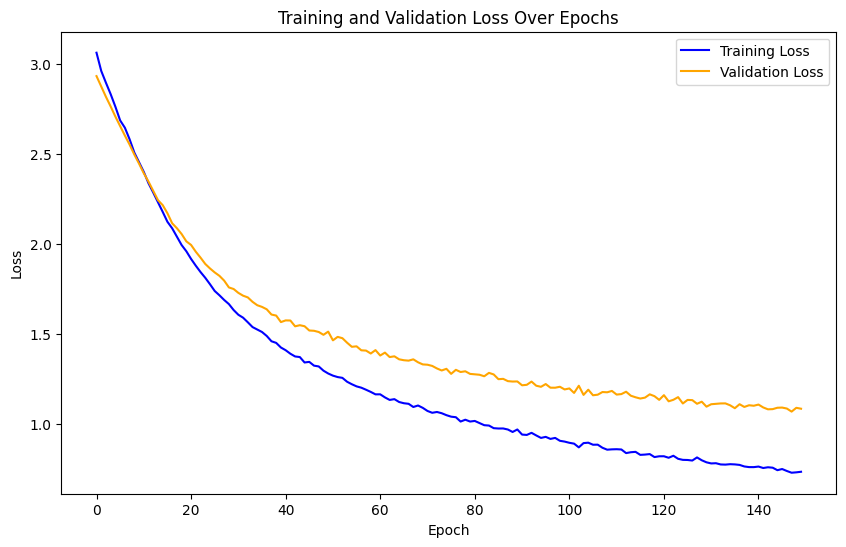

In [18]:
import json
import matplotlib.pyplot as plt

# Load the JSON data from the file
with open("training_hist_VGG19_version_2.json") as f:
    data = json.load(f)

# Extract loss and validation loss
loss = data['loss']
val_loss = data['val_loss']

# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')

# Add titles and labels
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()


In [19]:
class_name = list(training_set.class_indices.keys())
class_name


['Aloevera',
 'Amla',
 'Bamboo',
 'Bhrami',
 'Bringaraja',
 'Castor',
 'Coffee',
 'Coriender',
 'Curry',
 'Eucalyptus',
 'Ginger',
 'Guava',
 'Henna',
 'Hibiscus',
 'Lemon',
 'Mint',
 'Neem',
 'Onion',
 'Palak(Spinach)',
 'Papaya']

In [20]:
# Create test set for evaluation (without augmentation)
test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

test_set = test_datagen.flow_from_directory(
    'removed background',
    target_size=(224, 224),
    batch_size=16,  # Reduced from 32 to prevent OOM
    class_mode='categorical',
    subset='validation',
    shuffle=False,# one by one check all the directory
    seed=42
)


Found 1046 images belonging to 20 classes.


In [27]:
y_pred = model.predict(test_set)
y_pred


66/66 [==============================] - 24s 375ms/step


array([[9.9563688e-01, 8.9136738e-06, 3.5595582e-03, ..., 6.6544912e-06,
        2.5912515e-05, 4.1167306e-05],
       [6.6240281e-01, 2.1994808e-03, 7.7172490e-03, ..., 7.9054842e-03,
        8.3026366e-04, 2.8908111e-02],
       [6.8683350e-01, 1.9351166e-03, 5.7685967e-03, ..., 7.1728486e-03,
        6.4556161e-04, 3.1469665e-02],
       ...,
       [4.9006903e-06, 5.1214798e-08, 4.3034991e-08, ..., 1.5528889e-07,
        4.2008747e-08, 9.7567856e-01],
       [9.9001963e-06, 1.4667152e-07, 1.4708797e-07, ..., 6.3950677e-07,
        9.9432015e-08, 9.6436036e-01],
       [8.2000042e-06, 3.3238958e-08, 3.3629036e-08, ..., 7.8351533e-08,
        3.6087915e-08, 9.8957598e-01]], dtype=float32)

In [28]:
predicted_categories= tf.argmax(y_pred,axis=1)


In [29]:
# Reset test_set before reading labels (it was already used for predictions)
test_set.reset()

# Safely extract all true labels (one-hot encoded) from test_set
# This approach avoids generator issues by collecting labels in batches
true_categories_list = []
for x, y in test_set:
    true_categories_list.append(y)
    # Stop when we've processed all images (test_set has 1046 images)
    if len(true_categories_list) * test_set.batch_size >= test_set.samples:
        break

# Concatenate all batches into one tensor
true_categories = tf.concat(true_categories_list, axis=0)
true_categories #one hot encoding


<tf.Tensor: shape=(1046, 20), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [30]:
y_true= tf.argmax(true_categories,axis=1)
y_true


<tf.Tensor: shape=(1046,), dtype=int64, numpy=array([ 0,  0,  0, ..., 19, 19, 19], dtype=int64)>

In [31]:
from sklearn.metrics import classification_report , confusion_matrix
print(classification_report(y_true,predicted_categories ,target_names = class_name))


                precision    recall  f1-score   support

      Aloevera       0.80      0.85      0.82        60
          Amla       0.21      0.07      0.11        40
        Bamboo       0.82      0.88      0.85        52
        Bhrami       0.92      0.76      0.83        62
    Bringaraja       0.78      0.70      0.74        40
        Castor       0.92      0.90      0.91        63
        Coffee       0.68      1.00      0.81        45
     Coriender       1.00      0.91      0.95        57
         Curry       0.80      0.38      0.51        64
    Eucalyptus       0.90      0.64      0.75        42
        Ginger       0.84      0.90      0.87        40
         Guava       0.49      0.55      0.52        62
         Henna       0.62      0.51      0.56        45
      Hibiscus       0.18      0.26      0.21        58
         Lemon       0.76      0.62      0.68        55
          Mint       0.60      0.62      0.61        69
          Neem       0.68      0.84      0.75  

In [32]:
cm = confusion_matrix(y_true , predicted_categories)
cm.shape


(20, 20)

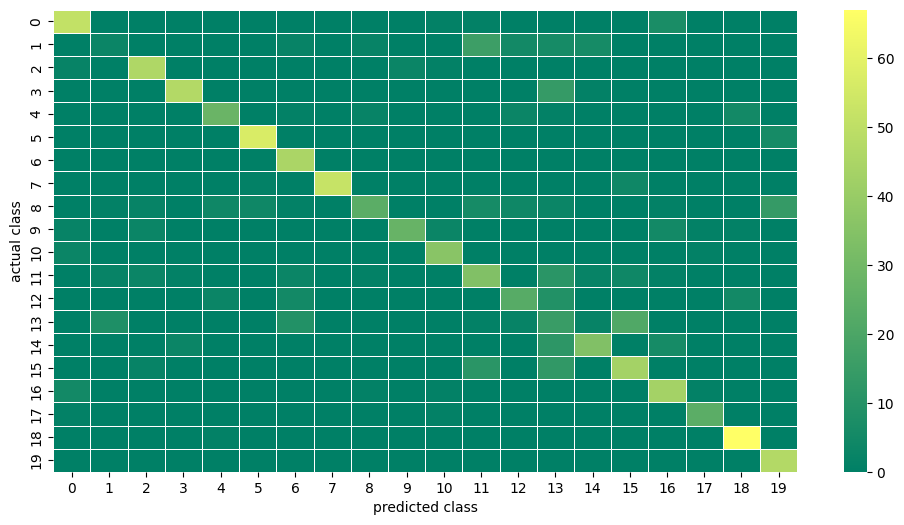

In [33]:
import seaborn as sns
plt.figure(figsize = (12,6))
sns.heatmap(cm,linewidth=0.5, cmap='summer')
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.show()


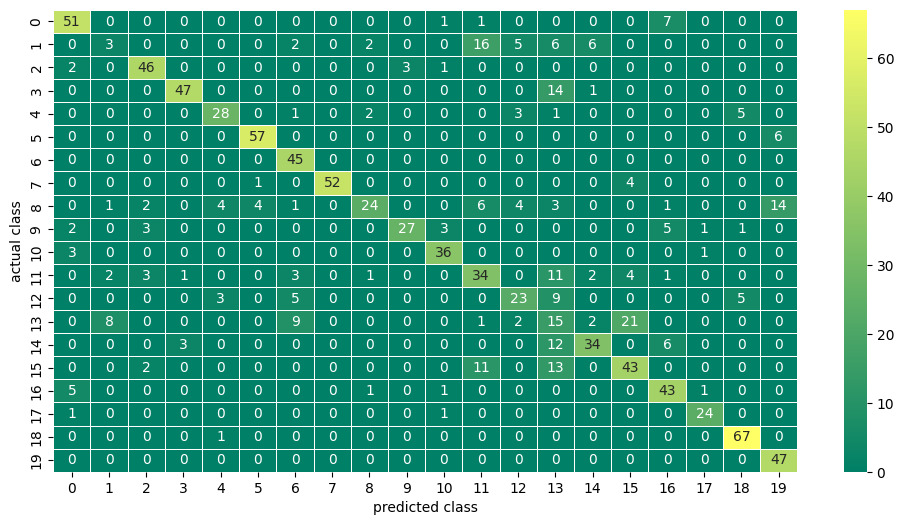

In [34]:
import seaborn as sns
plt.figure(figsize = (12,6))
sns.heatmap(cm,linewidth=0.5, cmap='summer' ,annot=True)
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.show()
